# 🐜 Heatmap for Figure 3

- custom code written by Mackenzie Mathis. For any questions, please reach out: mackenzie.mathis@epfl.ch

- this assumes you have the `h5` file outputs of the video analysis


In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


# Set up a bunch of useful functions!

- please see the docstrings for more details.

In [3]:
import sys
sys.path.append('/content/drive/MyDrive/Ants_Mackenzie_2024/')  # Add the directory containing your module
import utils_ant_analysis
from utils_ant_analysis import *

In [4]:
# DATA:
# for the figure, we use video 1 as an example

#the real deal:
#video 1:
file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_1DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'



tracked_keypoint_name = "ant_head"

In [5]:
df,bodyparts, scorer = load_data(file_path,smooth=True)

In [6]:
df.head(3)

scorer      DLC_dlcrnetms5_AntsFeb11shuffle1_100000                         \
individuals                                   ant_1                          
bodyparts                                  ant_head                          
coords                                            x           y likelihood   
0                                        115.770167  514.850000      0.982   
1                                        115.761667  514.741000      0.951   
2                                        115.756000  514.668333      0.961   

scorer                                                               \
individuals                                                           
bodyparts   ant_midbody                         ant_end               
coords                x           y likelihood        x           y   
0            107.877167  524.352000      0.849  108.009  531.799667   
1            107.857667  524.303000      0.414  107.889  531.624667   
2            107.844667  524.270333      0.541  107.809  531.508000   

scorer                            ...                                  \
individuals            drug_ant2  ...          single                   
bodyparts               ant_head  ... drug_pupa_pile1 drug_pupa_pile2   
coords      likelihood         x  ...      likelihood               x   
0                0.813  764.1695  ...             1.0      747.643167   
1                0.504  764.1660  ...             1.0      747.643667   
2                0.591  766.5800  ...             1.0      747.645333   

scorer                                                                     \
individuals                                                                 
bodyparts                          drug_pupa_pile3                          
coords                y likelihood               x           y likelihood   
0            223.373833        1.0      691.765667  284.648667        1.0   
1            223.374333        1.0      691.767667  284.656667        1.0   
2            223.375000        1.0      691.768667  284.659000        1.0   

scorer                                              
individuals                                         
bodyparts   drug_pupa_pile4                         
coords                    x           y likelihood  
0                754.147667  288.885333        1.0  
1                754.147667  288.886333        1.0  
2                754.147333  288.886667        1.0  

[3 rows x 108 columns]

# This is modified from the ant-analysis notebook to just make final heatmaps plots.

In [7]:
# whole zone for pretty plots
corner_names = ['corner1', 'corner2', 'corner3', 'corner4']
corner_order = ['corner1', 'corner2',  'corner4', 'corner3','corner1'] # Ensure correct order to close the rectangle

## Heatmap for paper plots:

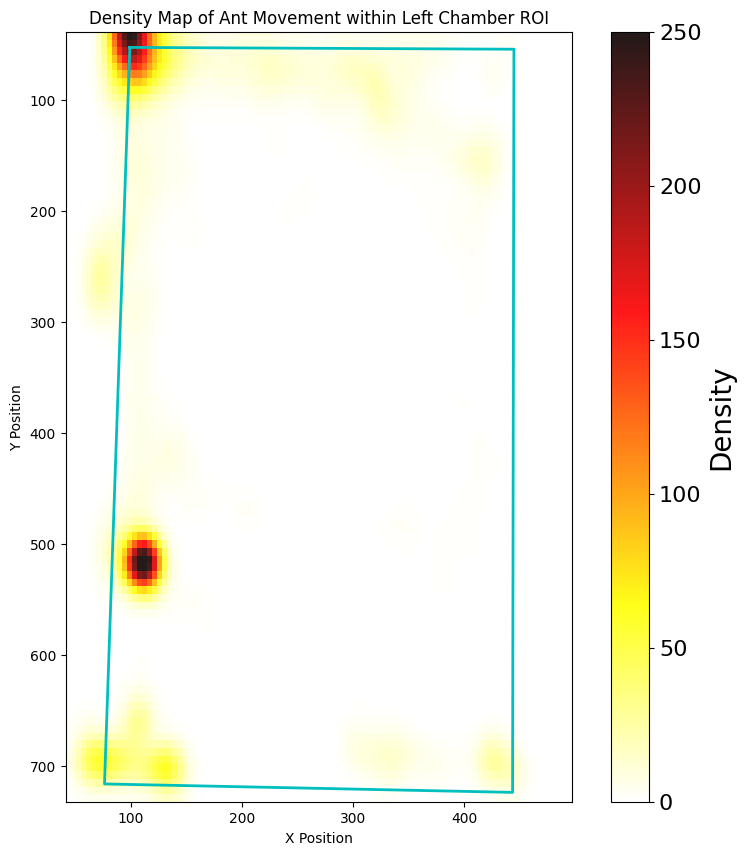

In [8]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

ants = ['ant_1', 'drug_ant2']


# Use the function to extract corner points over each frame
corner_points_over_frames = extract_corner_points_over_frames(df, scorer, corner_names)

# To display a small sample of the extracted points for verification
{corner: corner_points_over_frames[corner][:5] for corner in corner_points_over_frames}

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer,corner_names)

# Determine the bounds of the rectangle from corner points
xmin = min(min(point[0] for point in corner_points[corner]) for corner in corner_points)
xmax = max(max(point[0] for point in corner_points[corner]) for corner in corner_points)
ymin = min(min(point[1] for point in corner_points[corner]) for corner in corner_points)
ymax = max(max(point[1] for point in corner_points[corner]) for corner in corner_points)

# Extract a sample of corner points for plotting purposes
corner_sample = {corner: corner_points_over_frames[corner][:10] for corner in corner_points_over_frames}

# Extract positions for both ants and filter out NaN values
all_ants_x, all_ants_y = [], []

for ant in ants:
    ant_full_x = df[(scorer, ant, tracked_keypoint_name, 'x')].values
    ant_full_y = df[(scorer, ant, tracked_keypoint_name, 'y')].values
    valid_indices = ~np.isnan(ant_full_x) & ~np.isnan(ant_full_y)
    all_ants_x.extend(ant_full_x[valid_indices])
    all_ants_y.extend(ant_full_y[valid_indices])

# Create a combined 2D histogram for the "super ant"
grid_size = 100  # Adjust for resolution
heatmap, xedges, yedges = np.histogram2d(all_ants_x, all_ants_y, bins=grid_size, range=[[xmin, xmax], [ymin, ymax]])

# Apply Gaussian smoothing
heatmap_smoothed = gaussian_filter(heatmap, sigma=2)

# Plotting the density map with an adjusted aspect ratio
plt.figure(figsize=(19.2, 10.8))  # This will create a figure with the aspect ratio of the video
plt.imshow(heatmap_smoothed.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='hot_r', aspect='equal', alpha=0.9, vmin=0, vmax=250) #can also use turbo

# Overlay the rectangle defined by the corner points
rectangle_x = [corner_points[corner][0][0] for corner in corner_order]
rectangle_y = [corner_points[corner][0][1] for corner in corner_order]
plt.plot(rectangle_x, rectangle_y, 'c-', linewidth=2)  # Cyan lines to define the rectangle

# Setting the title with placeholders
plot_title = "Density Map of Ant Movement within Left Chamber ROI"
plt.title(plot_title)
plt.xlabel('X Position')
plt.ylabel('Y Position')

cbar = plt.colorbar(label='Density')
cbar.ax.set_ylabel('Density', fontsize=20)  # Set the font size for the colorbar label
cbar.ax.tick_params(labelsize=16)

plt.ylim(ymax, ymin)

# Adjust the figure size to match the video aspect ratio more closely
# This doesn't change the plot's aspect ratio but makes the figure window more visually accurate
video_aspect_ratio = 1920 / 1080
fig_aspect_ratio = video_aspect_ratio * (plt.gcf().get_size_inches()[1] / plt.gcf().get_size_inches()[0])
plt.gcf().set_size_inches(10, 10 / fig_aspect_ratio)



# Chamber 2:




In [9]:
# Define the list of ant identifiers you want to check
ants = ['ant_1', 'drug_ant2']

#for plotting on full area
corner_names = ['drug_corner1', 'drug_corner2', 'drug_corner3', 'drug_corner4']
corner_order = ['drug_corner1', 'drug_corner2', 'drug_corner4', 'drug_corner3','drug_corner1'] # Ensure correct order to close the rectangle


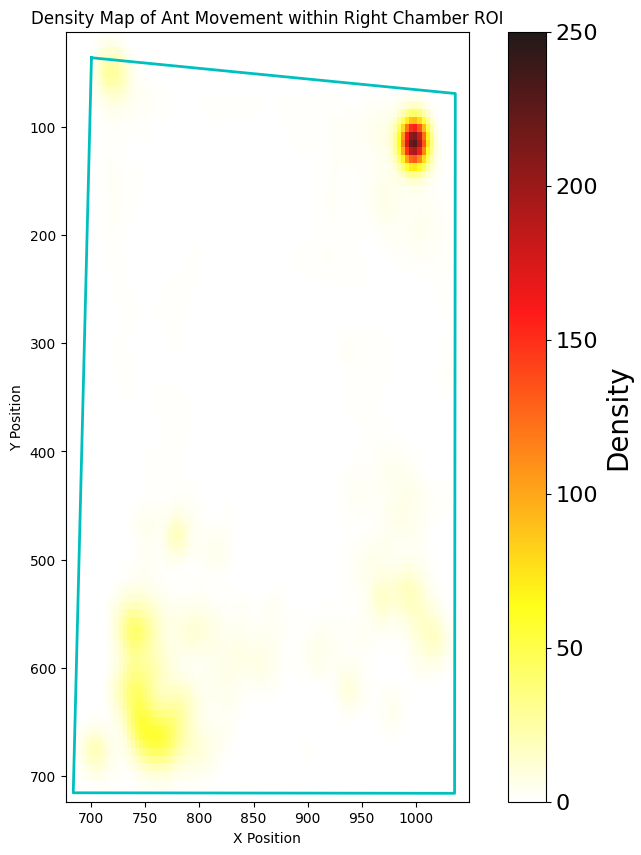

In [10]:
# Use the function to extract corner points over each frame
corner_points_over_frames = extract_corner_points_over_frames(df, scorer, corner_names)

# To display a small sample of the extracted points for verification
{corner: corner_points_over_frames[corner][:5] for corner in corner_points_over_frames}

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer,corner_names)

# Determine the bounds of the rectangle from corner points
xmin = min(min(point[0] for point in corner_points[corner]) for corner in corner_points)
xmax = max(max(point[0] for point in corner_points[corner]) for corner in corner_points)
ymin = min(min(point[1] for point in corner_points[corner]) for corner in corner_points)
ymax = max(max(point[1] for point in corner_points[corner]) for corner in corner_points)

# Extract a sample of corner points for plotting purposes
corner_sample = {corner: corner_points_over_frames[corner][:10] for corner in corner_points_over_frames}

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer, corner_names)

# Extract positions for both ants and filter out NaN values
all_ants_x, all_ants_y = [], []

for ant in ants:
    ant_full_x = df[(scorer, ant, tracked_keypoint_name, 'x')].values
    ant_full_y = df[(scorer, ant, tracked_keypoint_name, 'y')].values
    valid_indices = ~np.isnan(ant_full_x) & ~np.isnan(ant_full_y)
    all_ants_x.extend(ant_full_x[valid_indices])
    all_ants_y.extend(ant_full_y[valid_indices])

# Create a combined 2D histogram for the "super ant"
grid_size = 100  # Adjust for resolution
heatmap, xedges, yedges = np.histogram2d(all_ants_x, all_ants_y, bins=grid_size, range=[[xmin, xmax], [ymin, ymax]])

# Apply Gaussian smoothing
heatmap_smoothed = gaussian_filter(heatmap, sigma=2)

# Plotting the density map with an adjusted aspect ratio
plt.figure(figsize=(19.2, 10.8))  # This will create a figure with the aspect ratio of the video
plt.imshow(heatmap_smoothed.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='hot_r', aspect='equal', alpha=0.9, vmin=0, vmax=250) #can also use turbo

# Overlay the rectangle defined by the corner points
rectangle_x = [corner_points[corner][0][0] for corner in corner_order]
rectangle_y = [corner_points[corner][0][1] for corner in corner_order]
plt.plot(rectangle_x, rectangle_y, 'c-', linewidth=2)  # Cyan lines to define the rectangle

# Setting the title with placeholders
plot_title = "Density Map of Ant Movement within Right Chamber ROI"
plt.title(plot_title)
plt.xlabel('X Position')
plt.ylabel('Y Position')

cbar = plt.colorbar(label='Density')
cbar.ax.set_ylabel('Density', fontsize=20)  # Set the font size for the colorbar label
cbar.ax.tick_params(labelsize=16)

plt.ylim(ymax, ymin)

# Adjust the figure size to match the video aspect ratio more closely
# This doesn't change the plot's aspect ratio but makes the figure window more visually accurate
video_aspect_ratio = 1920 / 1080
fig_aspect_ratio = video_aspect_ratio * (plt.gcf().get_size_inches()[1] / plt.gcf().get_size_inches()[0])
plt.gcf().set_size_inches(10, 10 / fig_aspect_ratio)

